In [1]:
# =============================================================
# Libraries
# =============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
def load_heart_data():
    url="heart.csv"
    df=pd.read_csv(url)
    return df 

df = load_heart_data()
print("Shape:", df.shape)
df.head()

Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


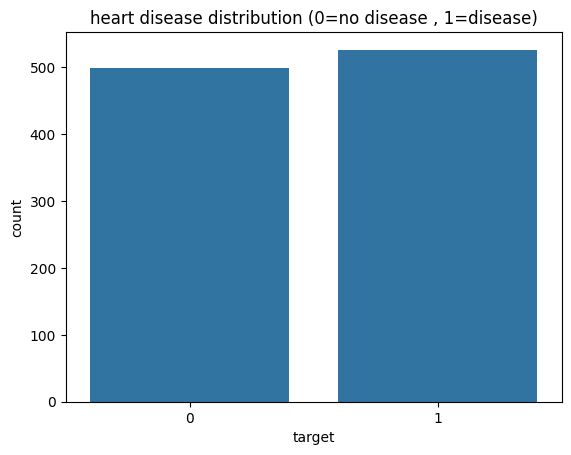

In [4]:
sns.countplot(x='target',data=df)
plt.title("heart disease distribution (0=no disease , 1=disease)")
plt.show()

In [9]:
def split_data(df):
    X=df.drop ( "target",axis=1)
    y=df["target"]
    return train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

X_train, X_test, y_train, y_test = split_data(df) 


In [24]:
def train_random_forrest(X_train, X_test, y_train, y_test):
    rf=RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42)
    rf.fit(X_train,y_train)
    preds=rf.predict(X_test)
    acc=accuracy_score(y_test,preds)
    return acc , preds
rf_acc,rf_preds=train_random_forrest(X_train, X_test, y_train, y_test)  
print("RandomForestClassifier accuracy :" , rf_acc)

RandomForestClassifier accuracy : 0.926829268292683


In [12]:
print(rf_preds)


[0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 1 1 0 1 0 0 1 0 1 1 1 1 0 0 1
 0 0 1 0 1 1 1 0 0 1 1 0 1 0 0 1 0 1 0 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 0 1 1
 0 0 1 0 0 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1 0 0 1 1
 0 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 1 0 0 0 0 1 1
 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 0 1 0 1 1 0 1 1 0
 1 0 0 0 1 0 1 1 0 1 0 1 1 1 1 0 0 0 1 1]


In [21]:
from sklearn.utils import resample
from scipy.stats   import mode 

def bagger_fit_predict(model_fns,X_train,y_train,X_test,n_estimators=15):
    all_preds=[]
    for fn in model_fns:
        for _ in range(n_estimators):
            
            X_bs,y_bs=resample(X_train,y_train,replace=True)
            model = fn()
            # Fit model
            model.fit(X_bs, y_bs)
            # Predict test set
            preds = model.predict(X_test)
            all_preds.append(preds)

    all_preds = np.array(all_preds)  
    final_preds = mode(all_preds, axis=0).mode  
    return final_preds.ravel()

model_list = [
    lambda: DecisionTreeClassifier(max_depth=5),
    lambda: KNeighborsClassifier(n_neighbors=5),
    lambda: LogisticRegression(max_iter=50)
]
bagger_preds = bagger_fit_predict(
    model_fns=model_list,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    n_estimators=15
)
bagger_acc = accuracy_score(y_test, bagger_preds)
print("Custom Bagger Accuracy:", bagger_acc)
        



Custom Bagger Accuracy: 0.8634146341463415


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 50 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=50).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 50 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=50).
You might also want to scale the data as shown in:
    https://scikit-learn.or

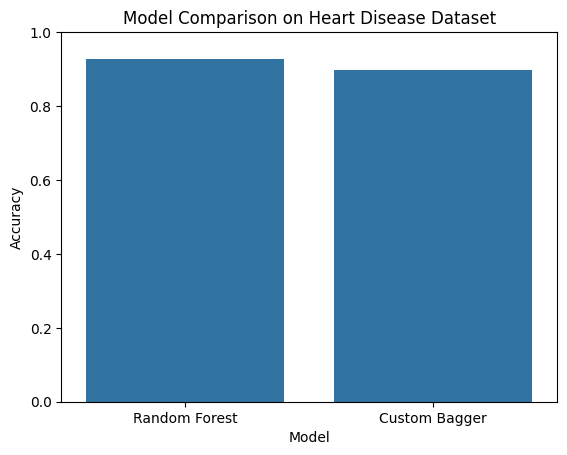

,Model,Accuracy
0,Random Forest,0.926829
1,Custom Bagger,0.897561


In [19]:

# Step 5  Compare All Models

results = pd.DataFrame({
    "Model": ["Random Forest", "Custom Bagger"],
    "Accuracy": [rf_acc, bagger_acc]
})

sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Comparison on Heart Disease Dataset")
plt.ylim(0, 1)
plt.show()

results


In [ ]:

#  Step 6 Evaluation Report

print("Classification Report (Custom Bagger):")
print(classification_report(y_test, bagger_preds))
